In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

class SOCDataset(Dataset):
    def __init__(self, file_paths, scaler=None, fit_scaler=False,
                 window_size=400, battery_capacity=3.0):
        self.window_size = window_size
        self.windows = []

        all_features_for_fit = []
        raw_data = []

        for path in file_paths:
            df = pd.read_csv(path, skiprows=28, low_memory=False)
            df = df.iloc[1:].copy()
            for col in ['Voltage', 'Current', 'Temperature', 'Capacity']:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            df = df.dropna(subset=['Voltage', 'Current', 'Temperature', 'Capacity'])

            features = df[['Voltage', 'Current', 'Temperature']].values.astype(np.float32)
            soc = (1 + df['Capacity'].values / battery_capacity).astype(np.float32)
            raw_data.append((features, soc))

            if fit_scaler:
                all_features_for_fit.append(features)

        if fit_scaler:
            all_features_concat = np.concatenate(all_features_for_fit)
            scaler.fit(all_features_concat)

        self.total_windows = 0
        for features, soc in raw_data:
            features_scaled = scaler.transform(features)
            n_windows = len(features_scaled) - window_size
            if n_windows > 0:
                self.windows.append((features_scaled, soc, self.total_windows))
                self.total_windows += n_windows

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        file_idx = 0
        for i, (features, soc, start) in enumerate(self.windows):
            n_windows = len(features) - self.window_size
            if idx < start + n_windows:
                file_idx = i
                local_idx = idx - start
                break

        features, soc, _ = self.windows[file_idx]
        X = features[local_idx : local_idx + self.window_size]
        y = soc[local_idx + self.window_size]
        return torch.FloatTensor(X), torch.FloatTensor([y])

base_dir = 'C:/LG_HG2_Original_Dataset_McMasterUniversity_Jan_2020/'

train_files = [
    base_dir + '25degC/551_Mixed1.csv',
    base_dir + '25degC/551_Mixed2.csv',
    base_dir + '25degC/552_Mixed3.csv',
    base_dir + '25degC/552_Mixed4.csv',
    base_dir + '25degC/552_Mixed5.csv',
    base_dir + '25degC/552_Mixed6.csv',
    base_dir + '25degC/552_Mixed7.csv',


    base_dir + '40degC/556_Mixed1.csv',
    base_dir + '40degC/556_Mixed2.csv',
    base_dir + '40degC/557_Mixed3.csv',
    base_dir + '40degC/562_Mixed4.csv',
    base_dir + '40degC/562_Mixed5.csv',
    base_dir + '40degC/562_Mixed6.csv',
    base_dir + '40degC/562_Mixed7.csv',


    base_dir + '10degC/567_Mixed1.csv',
    base_dir + '10degC/567_Mixed2.csv',
    base_dir + '10degC/571_Mixed4.csv',
    base_dir + '10degC/571_Mixed5.csv',
    base_dir + '10degC/571_Mixed6.csv',
    base_dir + '10degC/571_Mixed7.csv',


    base_dir + '0degC/589_Mixed1.csv',
    base_dir + '0degC/589_Mixed2.csv',
    base_dir + '0degC/590_Mixed4.csv',
    base_dir + '0degC/590_Mixed5.csv',
    base_dir + '0degC/590_Mixed6.csv',
    base_dir + '0degC/590_Mixed7.csv',


    base_dir + 'n10degC/601_Mixed1.csv',
    base_dir + 'n10degC/601_Mixed2.csv',
    base_dir + 'n10degC/602_Mixed4.csv',
    base_dir + 'n10degC/602_Mixed5.csv',
    base_dir + 'n10degC/604_Mixed3.csv',
    base_dir + 'n10degC/604_Mixed6.csv',
    base_dir + 'n10degC/604_Mixed7.csv',


    base_dir + 'n20degC/610_Mixed1.csv',
    base_dir + 'n20degC/610_Mixed2.csv',
    base_dir + 'n20degC/611_Mixed3.csv',
    base_dir + 'n20degC/611_Mixed4.csv',
    base_dir + 'n20degC/611_Mixed5.csv',
    base_dir + 'n20degC/611_Mixed6.csv',
    base_dir + 'n20degC/611_Mixed7.csv',
]

val_files = [
    base_dir + '25degC/552_Mixed8.csv',
    base_dir + '40degC/562_Mixed8.csv',
    base_dir + '10degC/571_Mixed8.csv',
    base_dir + '0degC/590_Mixed8.csv',
    base_dir + 'n10degC/604_Mixed8.csv',
    base_dir + 'n20degC/611_Mixed8.csv',
]

test_files = [
    base_dir + '25degC/551_UDDS.csv',
    base_dir + '25degC/551_LA92.csv',
    base_dir + '25degC/551_US06.csv',

    base_dir + '40degC/556_UDDS.csv',
    base_dir + '40degC/556_LA92.csv',
    base_dir + '40degC/556_US06.csv',

    base_dir + '10degC/576_UDDS.csv',
    base_dir + '10degC/582_LA92.csv',
    base_dir + '10degC/567_US06.csv',

    base_dir + '0degC/589_UDDS.csv',
    base_dir + '0degC/589_LA92.csv',
    base_dir + '0degC/589_US06.csv',

    base_dir + 'n10degC/596_UDDS.csv',
    base_dir + 'n10degC/596_LA92.csv',
    base_dir + 'n10degC/601_US06.csv',

    base_dir + 'n20degC/610_UDDS.csv',
    base_dir + 'n20degC/610_LA92.csv',
    base_dir + 'n20degC/610_US06.csv',
]

test_temp_labels = ['25°C'] * 3 + ['40°C'] * 3 + ['10°C'] * 3 + \
                   ['0°C'] * 3 + ['-10°C'] * 3 + ['-20°C'] * 3

scaler = MinMaxScaler()

train_dataset = SOCDataset(train_files, scaler=scaler, fit_scaler=True)
val_dataset   = SOCDataset(val_files,   scaler=scaler, fit_scaler=False)
test_dataset  = SOCDataset(test_files,  scaler=scaler, fit_scaler=False)

print(f"Train windows: {len(train_dataset)}")
print(f"Val windows:   {len(val_dataset)}")
print(f"Test windows:  {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False, num_workers=0, pin_memory=True)

Train windows: 2346337
Val windows:   369248
Test windows:  1514705


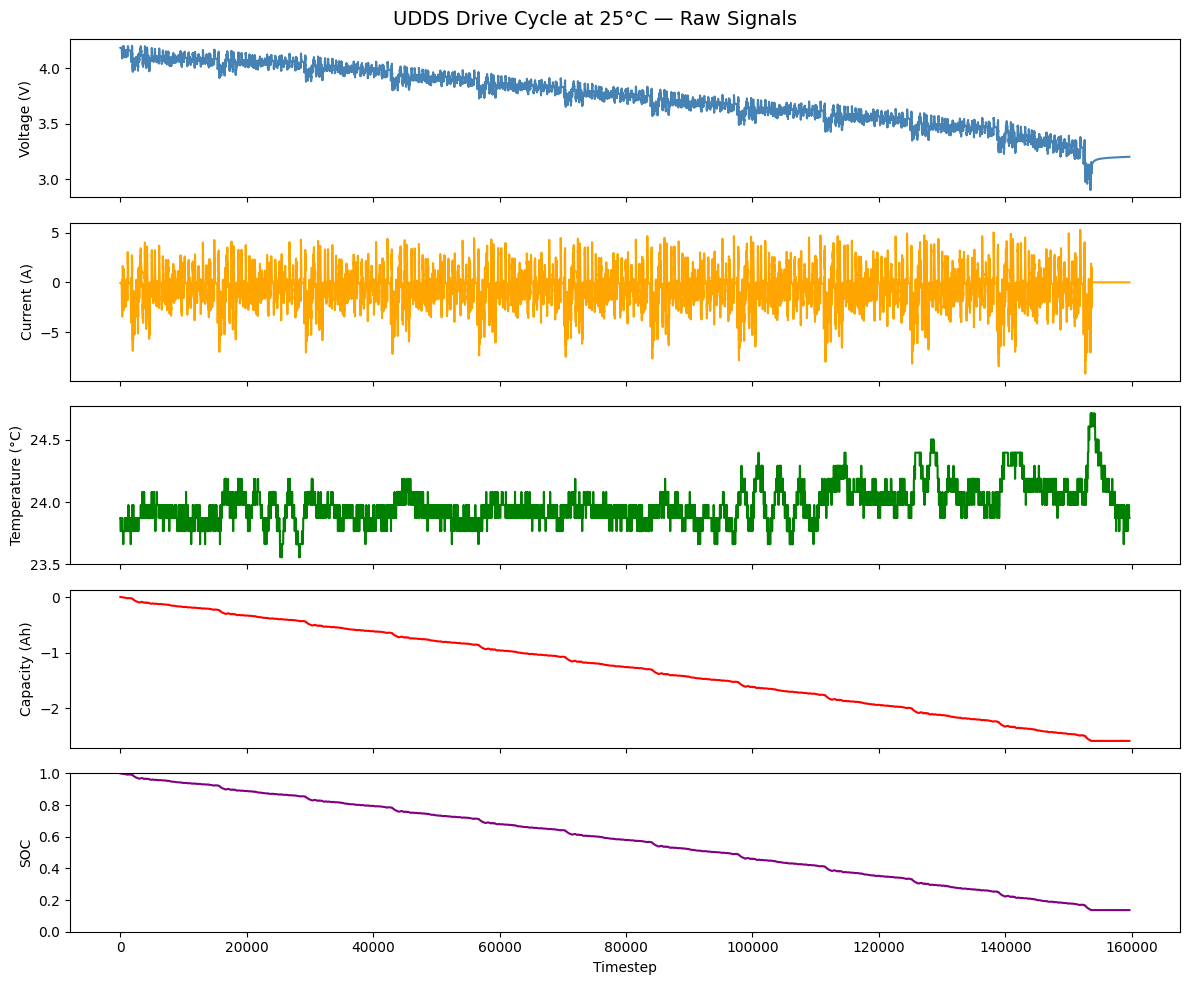

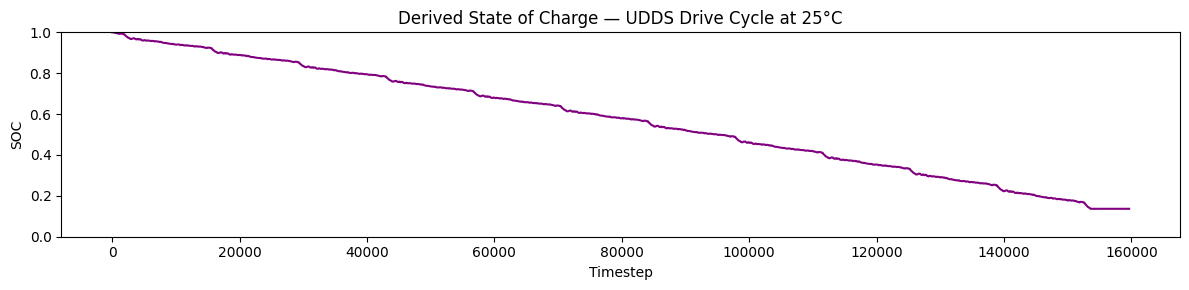

SOC range: 0.137 to 1.000
Timesteps: 159646


In [ ]:
import matplotlib.pyplot as plt


BATTERY_CAPACITY = 3.0
explore_path = '/LG_HG2_Original_Dataset_McMasterUniversity_Jan_2020/25degC/551_UDDS.csv'

df_explore = pd.read_csv(explore_path, skiprows=28, low_memory=False)
df_explore = df_explore.iloc[1:].copy()

for col in ['Voltage', 'Current', 'Temperature', 'Capacity']:
    df_explore[col] = pd.to_numeric(df_explore[col], errors='coerce')

df_explore = df_explore.dropna(subset=['Voltage', 'Current', 'Temperature', 'Capacity'])
df_explore['SOC'] = 1 + (df_explore['Capacity'] / BATTERY_CAPACITY)

# plot raw signals
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
fig.suptitle('UDDS Drive Cycle at 25°C — Raw Signals', fontsize=14)

axes[0].plot(df_explore['Voltage'].values, color='steelblue')
axes[0].set_ylabel('Voltage (V)')

axes[1].plot(df_explore['Current'].values, color='orange')
axes[1].set_ylabel('Current (A)')

axes[2].plot(df_explore['Temperature'].values, color='green')
axes[2].set_ylabel('Temperature (°C)')

axes[3].plot(df_explore['Capacity'].values, color='red')
axes[3].set_ylabel('Capacity (Ah)')

axes[4].plot(df_explore['SOC'].values, color='purple')
axes[4].set_ylabel('SOC')
axes[4].set_ylim(0, 1)

plt.xlabel('Timestep')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(df_explore['SOC'].values, color='purple')
plt.ylabel('SOC')
plt.xlabel('Timestep')
plt.title('Derived State of Charge — UDDS Drive Cycle at 25°C')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"SOC range: {df_explore['SOC'].min():.3f} to {df_explore['SOC'].max():.3f}")
print(f"Timesteps: {len(df_explore)}")

In [ ]:
X_batch, y_batch = next(iter(train_loader))
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)

X_batch shape: torch.Size([32, 400, 3])
y_batch shape: torch.Size([32, 1])


In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=100, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.fc(last_step)

model = LSTMModel()
print(model)

with torch.no_grad():
    test_out = model(X_batch)
    print("Output shape:", test_out.shape)

LSTMModel(
  (lstm): LSTM(3, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
Output shape: torch.Size([32, 1])


Using device: cuda
Epoch 1/100 | Val Loss: 0.000429
  → Best model saved
Epoch 2/100 | Val Loss: 0.000374
  → Best model saved
Epoch 3/100 | Val Loss: 0.013688
Epoch 4/100 | Val Loss: 0.000409
Epoch 5/100 | Val Loss: 0.000179
  → Best model saved
Epoch 6/100 | Val Loss: 0.000105
  → Best model saved
Epoch 7/100 | Val Loss: 0.000231
Epoch 8/100 | Val Loss: 0.000730
Epoch 9/100 | Val Loss: 0.000107
Epoch 10/100 | Val Loss: 0.002942
Epoch 11/100 | Val Loss: 0.000330
Epoch 12/100 | Val Loss: 0.000240
Epoch 13/100 | Val Loss: 0.000161
Epoch 14/100 | Val Loss: 0.000103
  → Best model saved
Epoch 15/100 | Val Loss: 0.000361
Epoch 16/100 | Val Loss: 0.000086
  → Best model saved
Epoch 17/100 | Val Loss: 0.000121
Epoch 18/100 | Val Loss: 0.000080
  → Best model saved
Epoch 19/100 | Val Loss: 0.000048
  → Best model saved
Epoch 20/100 | Val Loss: 0.000059
Epoch 21/100 | Val Loss: 0.000061
Epoch 22/100 | Val Loss: 0.000061
Epoch 23/100 | Val Loss: 0.000046
  → Best model saved
Epoch 24/100 | Val 

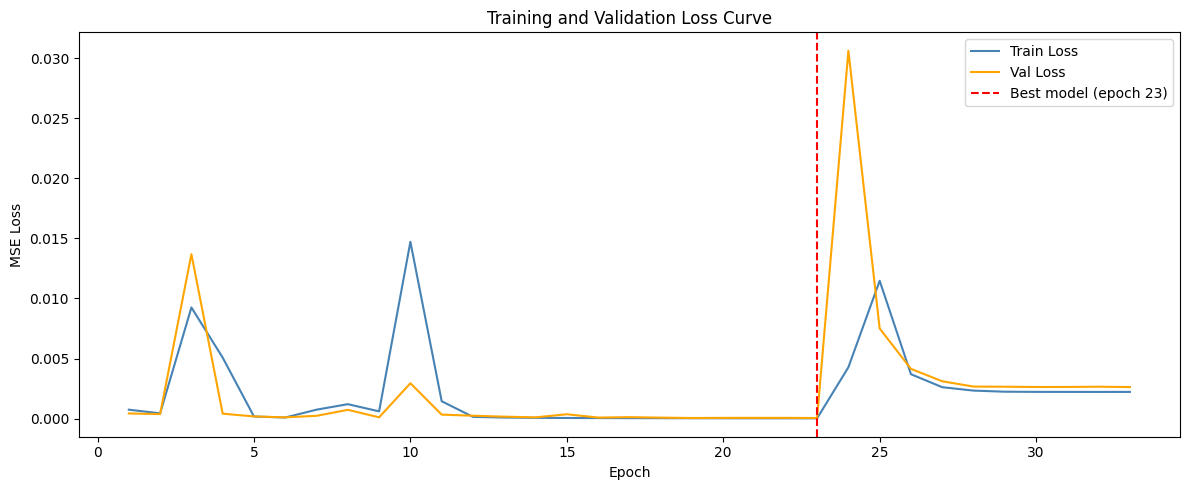

Best validation loss: 0.000046 at epoch 23
Corresponding RMSE: 0.6793%


In [ ]:
import os
import torch.nn as nn
import torch.optim
import matplotlib.pyplot as plt

os.makedirs('./checkpoints', exist_ok=True)
device = torch.device('cuda')
print(f"Using device: {device}")

torch.manual_seed(10)
torch.cuda.manual_seed(10)

model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100


best_val_loss = float('inf')
patience = 10
epochs_without_improvement = 0

train_losses = []
val_losses_history = []

for epoch in range(num_epochs):

    # training
    model.train()
    current_train_losses = []
    for X_batch, y_batch in train_loader:
        # move batches to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        current_train_losses.append(loss.item())
    train_losses.append(sum(current_train_losses) / len(current_train_losses))

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_losses.append(loss.item())

    val_loss = sum(val_losses) / len(val_losses)
    val_losses_history.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), './checkpoints/best_model_table2.pth')
        print(f"  → Best model saved")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

best_epoch = val_losses_history.index(min(val_losses_history)) + 1

plt.figure(figsize=(12, 5))
epochs_ran = len(train_losses)
plt.plot(range(1, epochs_ran+1), train_losses, label='Train Loss', color='steelblue')
plt.plot(range(1, epochs_ran+1), val_losses_history, label='Val Loss', color='orange')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best model (epoch {best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best validation loss: {min(val_losses_history):.6f} at epoch {best_epoch}")
print(f"Corresponding RMSE: {(min(val_losses_history)**0.5)*100:.4f}%")

Overall Test RMSE: 0.7933%
Overall Test MAE:  0.5539%

Temp     File                          RMSE      MAE
-----------------------------------------------------
25°C     551_UDDS.csv               0.4118%  0.3360%
25°C     551_LA92.csv               0.4676%  0.3632%
25°C     551_US06.csv               0.7512%  0.6125%
40°C     556_UDDS.csv               0.4559%  0.3876%
40°C     556_LA92.csv               0.3375%  0.2604%
40°C     556_US06.csv               0.5331%  0.4207%
10°C     576_UDDS.csv               0.6011%  0.4257%
10°C     582_LA92.csv               0.8044%  0.6901%
10°C     567_US06.csv               0.6871%  0.4845%
0°C      589_UDDS.csv               0.7426%  0.5182%
0°C      589_LA92.csv               0.5196%  0.4126%
0°C      589_US06.csv               1.0679%  0.7628%
-10°C    596_UDDS.csv               1.3302%  0.9294%
-10°C    596_LA92.csv               0.9363%  0.7527%
-10°C    601_US06.csv               0.9782%  0.7214%
-20°C    610_UDDS.csv               1.5059%

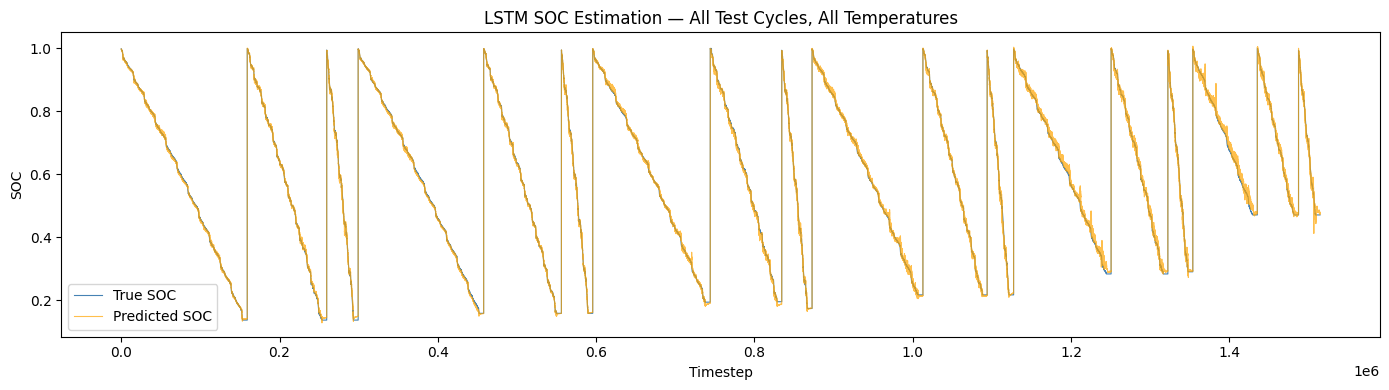

In [ ]:
model.load_state_dict(torch.load('./checkpoints/best_model_table2.pth'))
model.eval()

all_preds = []
all_true  = []
per_file_results = []

for file_idx, (features, soc, start) in enumerate(test_dataset.windows):
    n_windows = len(features) - test_dataset.window_size

    file_indices = list(range(start, start + n_windows))
    file_subset  = torch.utils.data.Subset(test_dataset, file_indices)
    file_loader  = DataLoader(file_subset, batch_size=1024, shuffle=False, num_workers=0)

    file_preds = []
    file_true  = []

    with torch.no_grad():
        for X_batch, y_batch in file_loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().squeeze().tolist()
            file_preds.extend(preds)
            file_true_batch = y_batch.squeeze().tolist()
            if isinstance(file_true_batch, float):
              file_true_batch = [file_true_batch]
            file_true.extend(file_true_batch)

    file_preds = np.array(file_preds)
    file_true  = np.array(file_true)

    file_rmse = np.sqrt(np.mean((file_preds - file_true)**2))
    file_mae  = np.mean(np.abs(file_preds - file_true))

    temp_label = test_temp_labels[file_idx]
    fname      = test_files[file_idx].split('/')[-1]
    per_file_results.append((temp_label, fname, file_rmse, file_mae))

    all_preds.extend(file_preds.tolist())
    all_true.extend(file_true.tolist())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

overall_rmse = np.sqrt(np.mean((all_preds - all_true)**2))
overall_mae  = np.mean(np.abs(all_preds - all_true))
print(f"Overall Test RMSE: {overall_rmse*100:.4f}%")
print(f"Overall Test MAE:  {overall_mae*100:.4f}%\n")

print(f"{'Temp':<8} {'File':<25} {'RMSE':>8} {'MAE':>8}")
print("-" * 53)
for temp, fname, rmse, mae in per_file_results:
    print(f"{temp:<8} {fname:<25} {rmse*100:>7.4f}% {mae*100:>7.4f}%")

plt.figure(figsize=(14, 4))
plt.plot(all_true,  label='True SOC',      linewidth=0.8, color='steelblue')
plt.plot(all_preds, label='Predicted SOC', linewidth=0.8, color='orange', alpha=0.7)
plt.xlabel('Timestep')
plt.ylabel('SOC')
plt.title('LSTM SOC Estimation — All Test Cycles, All Temperatures')
plt.legend()
plt.tight_layout()
plt.show()